# 🌴 บทที่ 1 — รู้จักข้อมูล ก่อนที่คอมพิวเตอร์จะ "มองเห็น" พื้นที่ปลูกปาล์ม

> **สื่อการสอน Workshop:** การจำแนกพื้นที่ปลูกปาล์มน้ำมันด้วยภาพถ่ายดาวเทียมและ AI  
> ระดับ: สำหรับผู้เริ่มต้น ไม่จำเป็นต้องมีพื้นฐานด้านภูมิสารสนเทศหรือ AI มาก่อน

---

## บทที่ 1 นี้ เราจะทำอะไร?

ลองนึกภาพว่าเราต้องการให้คอมพิวเตอร์ "รู้จัก" ว่าพื้นที่ไหนคือสวนปาล์ม  
ก่อนที่เราจะสอนให้มันรู้จัก — เราเองต้องรู้จักข้อมูลที่จะใช้สอนก่อน

ในบทนี้เราจะ:
1. ทำความรู้จักกับ **ข้อมูล 4 ชนิด** ที่เกี่ยวข้องกับงานนี้
2. เรียนรู้วิธี **เปิดและดูข้อมูล** ด้วย Python บน Google Colab
3. **แสดงผลข้อมูล** บนหน้าจอเพื่อให้เห็นภาพ
4. เรียนรู้เบื้องต้นเกี่ยวกับ **Sentinel-3** และการใช้งานด้านสุขภาพพืช

---

## ข้อมูลที่เราใช้ใน Workshop นี้
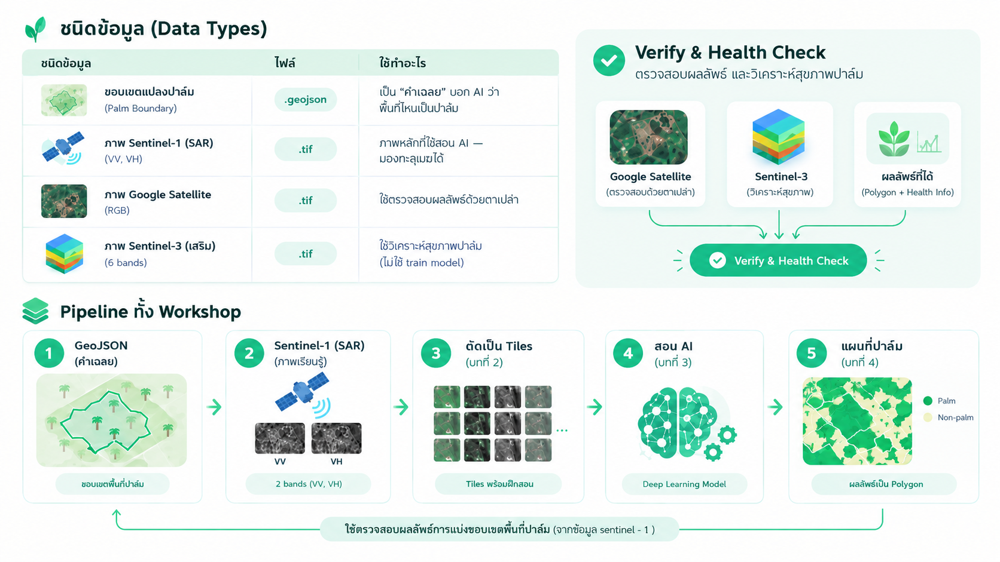


---

## 🛰️ ทำไมต้องใช้ภาพดาวเทียมแบบพิเศษ (Sentinel-1 SAR)?

ภาพจาก Google Maps ที่เราคุ้นเคยนั้นดีมาก แต่มีข้อจำกัดสำคัญ:

> **ปัญหา:** ภาคใต้ของไทยมีเมฆปกคลุมเกือบตลอดปี  
> กล้องถ่ายภาพธรรมดา "มองไม่เห็น" พื้นดินเมื่อมีเมฆ

**วิธีแก้ปัญหา:** ใช้ดาวเทียม Sentinel-1 ที่ทำงานด้วย **คลื่นไมโครเวฟ (SAR)**  
(Synthetic Aperture Radar — เรดาร์สังเคราะห์)

<!-- 🖼️ โครงสร้างสำหรับสร้างรูปประกอบ (ผู้สอนจะนำไปสร้างภาพจริงมาใส่แทน) -->
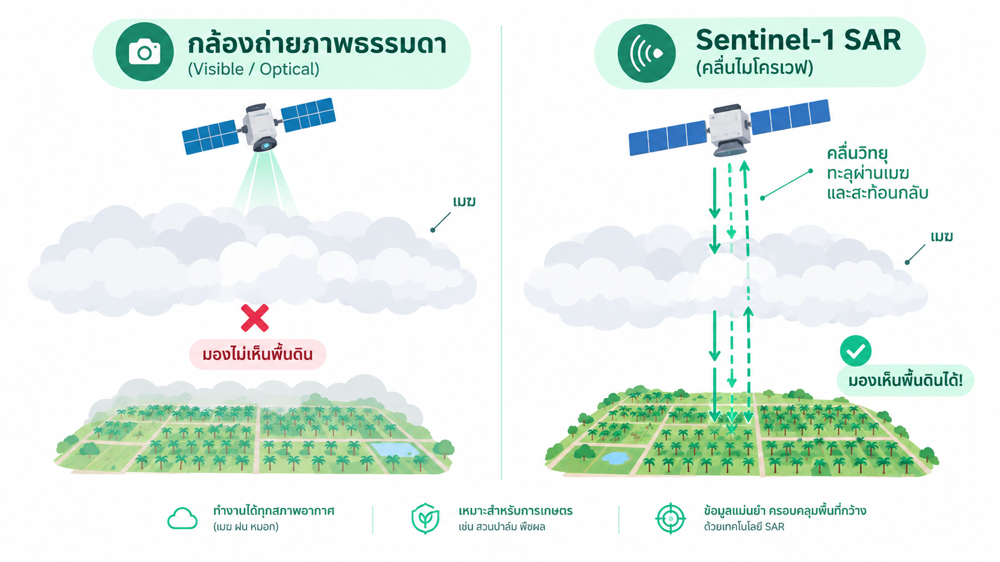

**Sentinel-1 ถ่ายภาพด้วยคลื่น 2 แบบ:**

| Polarization | ชื่อเต็ม | จำง่ายๆ |
|---|---|---|
| **VV** | Vertical-Vertical | ส่งแนวตั้ง → รับแนวตั้ง — เหมาะดูพื้นผิวราบ น้ำ |
| **VH** | Vertical-Horizontal | ส่งแนวตั้ง → รับแนวนอน — เหมาะดูใบไม้ ต้นไม้ |

> 💡 **จำง่ายๆ:** VH ไวต่อพืชพรรณ — ใบปาล์มสะท้อนคลื่นได้ดี ทำให้แยกออกจากพื้นดินว่างเปล่า  
> ในงานนี้เราใช้ **ทั้ง VV และ VH รวมกัน** เป็นข้อมูล 2 ชั้น (2 bands) ให้ AI เรียนรู้

---

## ขั้นตอนที่ 1 — เตรียม Google Colab

### Colab คืออะไร?

**Google Colab** คือบริการของ Google ที่ให้เราเขียนและรันโปรแกรม Python ได้ฟรีผ่านเบราว์เซอร์  
โดยไม่ต้องติดตั้งอะไรในเครื่องคอมพิวเตอร์เลย


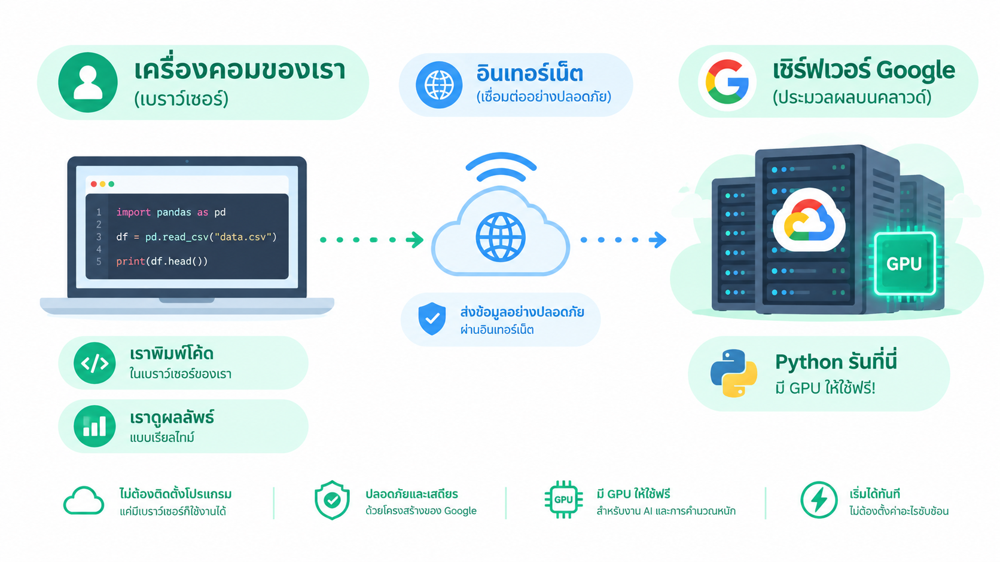

### วิธีรันโค้ด

- คลิกที่ **▶ (ปุ่มเล่น)** ทางซ้ายของ cell  
- หรือกด **Shift + Enter** บนแป้นพิมพ์
- รอจนเครื่องหมาย ▶ เปลี่ยนเป็น ✓ แล้วค่อยไป cell ต่อไป

> ⚠️ **สำคัญ:** ต้องรันตามลำดับจากบนลงล่างเสมอ ห้ามข้าม cell ในการ run ครั้งแรก

In [1]:
# =====================================================================
# ⚠️ สำหรับรันบน Local Machine (เครื่องตัวเอง)
# =====================================================================
import os
BASE_DIR = r'C:\Users\kittisak\Downloads\ssb tutor\drive_structure\ch01_sar_data'


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 1.1 — ติดตั้ง library ที่จำเป็น
# ═══════════════════════════════════════════════════════════
# Library คือ "กล่องเครื่องมือ" ที่คนอื่นเขียนไว้ให้เราใช้
# เหมือนกับการซื้อเครื่องครัวสำเร็จรูป แทนที่จะทำเองตั้งแต่ต้น

# !pip install rasterio geopandas matplotlib numpy --quiet

print("✅ ติดตั้งเครื่องมือเสร็จแล้ว พร้อมใช้งาน!")

✅ ติดตั้งเครื่องมือเสร็จแล้ว พร้อมใช้งาน!


In [3]:
# ═══════════════════════════════════════════════════════════
# CELL 1.2 — เรียกใช้ library
# ═══════════════════════════════════════════════════════════
# "import" = บอกให้ Python เปิดกล่องเครื่องมือที่ต้องการ

import os                    # เครื่องมือจัดการไฟล์และโฟลเดอร์
import numpy as np           # เครื่องมือคำนวณตัวเลขขนาดใหญ่
import matplotlib.pyplot as plt  # เครื่องมือวาดกราฟและแสดงภาพ
import rasterio              # เครื่องมืออ่านภาพดาวเทียม (.tif)
import geopandas as gpd      # เครื่องมืออ่านข้อมูลแผนที่ (.geojson)

print("✅ พร้อมแล้ว! เครื่องมือทั้งหมดพร้อมใช้งาน")
print()
print("เครื่องมือที่โหลดมา:")
print(f"  • NumPy    v{np.__version__}  — คำนวณตัวเลข")
print(f"  • Rasterio v{rasterio.__version__}  — อ่านภาพดาวเทียม")
print(f"  • GeoPandas v{gpd.__version__} — อ่านข้อมูลแผนที่")

✅ พร้อมแล้ว! เครื่องมือทั้งหมดพร้อมใช้งาน

เครื่องมือที่โหลดมา:
  • NumPy    v2.2.6  — คำนวณตัวเลข
  • Rasterio v1.4.4  — อ่านภาพดาวเทียม
  • GeoPandas v1.1.4 — อ่านข้อมูลแผนที่


---

## ขั้นตอนที่ 2 — เชื่อมต่อ Google Drive และระบุตำแหน่งไฟล์

เราจะเก็บไฟล์ข้อมูลทั้งหมดไว้ใน **Google Drive** เพื่อให้เข้าถึงได้ง่ายจาก Colab

### โครงสร้างโฟลเดอร์ที่ต้องเตรียม:

```
My Drive/
└── 📁 ssb_workshop/
    ├── 📁 vectors/
    │   └── 📄 reference_extent2_fixgeom.geojson     ← ขอบเขตแปลงปาล์ม (4,726 แปลง)
    └── 📁 rasters/
        ├── 🛰️ Sentinel-1_IW_mosaic_2026_M01_...tif  ← ภาพ SAR เดือน ม.ค. 2026
        ├── 🛰️ Sentinel-1_IW_mosaic_2026_M02_...tif  ← ภาพ SAR เดือน ก.พ. 2026
        ├── 🛰️ ...                                   ← (ภาพ SAR เดือนอื่นๆ)
        ├── 🛰️ Sentinel-1_IW_mosaic_2026_M05_...tif  ← ภาพ SAR สำหรับทดสอบ (hold-out)
        └── 🗺️ google_sat.tif                        ← ภาพ Google Satellite
```

> 📌 **หมายเหตุ:** ไฟล์ SAR ตั้งชื่อตามรูปแบบ `Sentinel-1_IW_mosaic_{YYYY}_{MM}_...` เช่น `2026_M01` = มกราคม 2026  
> โค้ดในบทถัดไปจะอ่านชื่อเหล่านี้โดยอัตโนมัติเพื่อแบ่ง training/holdout

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL 2.1 — เชื่อมต่อ Google Drive
# ═══════════════════════════════════════════════════════════
# เมื่อรัน cell นี้ จะมีหน้าต่างขอ permission ปรากฏขึ้น
# ให้คลิก "Connect to Google Drive" และเลือก Google Account ของคุณ
# from google.colab import drive
# drive.mount('/content/drive')
# BASE_DIR = '/content/drive/MyDrive/ssb_workshop/ch01_sar_data'

print("✅ เชื่อมต่อ Google Drive สำเร็จ!")

In [ ]:
VECTOR_PATH = os.path.join(BASE_DIR, "vectors/reference_extent2_fixgeom.geojson")

# ภาพ SAR — ใช้ไฟล์เดือน M01 เป็นตัวอย่างหลักในบทนี้
RASTER_DIR  = os.path.join(BASE_DIR, "rasters")

# ภาพ Google Satellite
SAT_PATH = os.path.join(BASE_DIR, "rasters/google_sat.tif")

# ── ตรวจสอบว่าพบไฟล์ครบหรือไม่ ──
print("🔍 ตรวจสอบไฟล์:")
all_ok = True

# ตรวจ vector
found = os.path.exists(VECTOR_PATH)
print(f"  {'✅' if found else '❌'} ขอบเขตแปลงปาล์ม (.geojson)")
if not found:
    all_ok = False
    print(f"     ไม่พบที่: {VECTOR_PATH}")

# ตรวจ rasters — หาไฟล์ SAR ทั้งหมด
import glob
sar_files = sorted(glob.glob(os.path.join(RASTER_DIR, "Sentinel-1*.tif")))
print(f"  {'✅' if len(sar_files) > 0 else '❌'} ภาพ Sentinel-1 SAR พบ {len(sar_files)} ไฟล์")
for f in sar_files:
    print(f"     • {os.path.basename(f)}")
if not sar_files:
    all_ok = False

# เลือก SAR ไฟล์แรกเป็นตัวอย่าง
SAR_PATH = sar_files[0] if sar_files else None
if SAR_PATH:
    print(f"  📌 ใช้ไฟล์นี้เป็นตัวอย่าง: {os.path.basename(SAR_PATH)}")

# ตรวจ Google Sat
found_sat = os.path.exists(SAT_PATH)
print(f"  {'✅' if found_sat else '⚠️'} ภาพ Google Satellite")
if not found_sat:
    print(f"     ไม่พบที่: {SAT_PATH} (ไม่บังคับ — ใช้ตรวจสอบผลลัพธ์ภายหลัง)")

print()
if all_ok:
    print("✅ พบไฟล์ครบทุกไฟล์ พร้อมไปต่อ!")
else:
    print("❌ ไม่พบไฟล์บางส่วน — กรุณาตรวจสอบชื่อโฟลเดอร์และไฟล์ใน Google Drive")

🔍 ตรวจสอบไฟล์:
  ✅ ขอบเขตแปลงปาล์ม (.geojson)
  ✅ ภาพ Sentinel-1 SAR พบ 7 ไฟล์
     • Sentinel-1_IW_mosaic_2025_M12_47PQQ_0_0_clif.tif
     • Sentinel-1_IW_mosaic_2026_M01_47PQQ_0_0_clif.tif
     • Sentinel-1_IW_mosaic_2026_M02_47PQQ_0_0_clif.tif
     • Sentinel-1_IW_mosaic_2026_M03_47PQQ_0_0_clif.tif
     • Sentinel-1_IW_mosaic_2026_M04_47PQQ_0_0_clif.tif
     • Sentinel-1_IW_mosaic_2026_M05_47PQQ_0_0.tif
     • Sentinel-1_IW_mosaic_2026_M05_47PQQ_0_0_clif.tif
  📌 ใช้ไฟล์นี้เป็นตัวอย่าง: Sentinel-1_IW_mosaic_2025_M12_47PQQ_0_0_clif.tif

✅ พบไฟล์ครบทุกไฟล์ พร้อมไปต่อ!


---

## ขั้นตอนที่ 3 — อ่านและทำความเข้าใจข้อมูลแปลงปาล์ม (GeoJSON)

### GeoJSON คืออะไร?

**GeoJSON** คือไฟล์ข้อความที่เก็บข้อมูลรูปร่างและตำแหน่งทางภูมิศาสตร์  
เปรียบเหมือนไฟล์ Excel แต่แต่ละแถวคือ "แปลงที่ดิน" ที่มีพิกัดบอกขอบเขต

ในที่นี้ GeoJSON ของเราคือ **"คำเฉลย"** — บอกว่าพื้นที่ไหนคือสวนปาล์มจริงๆ  
เราจะใช้มันเป็น **Label (ป้ายคำตอบ)** ในการสอน AI

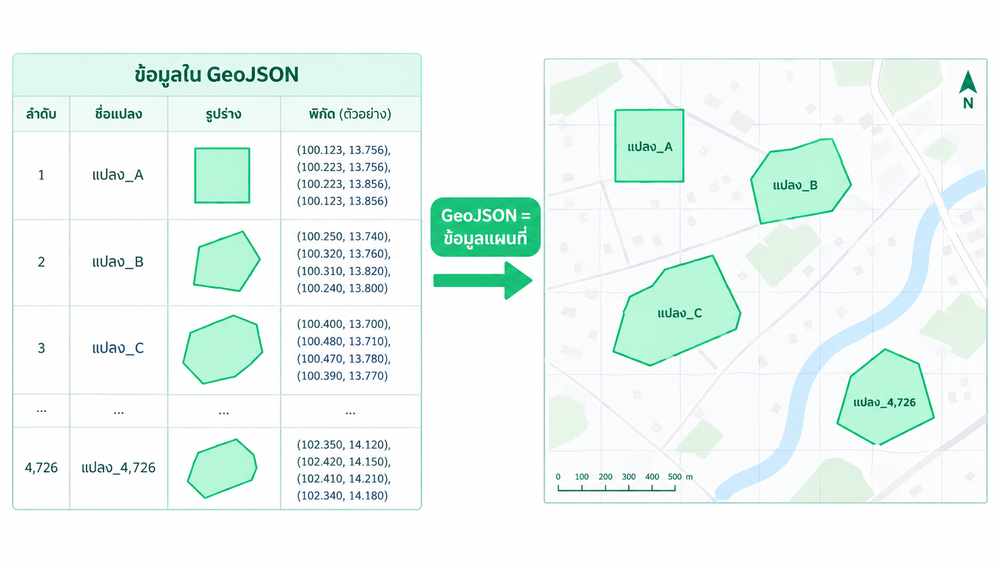

In [11]:
# ═══════════════════════════════════════════════════════════
# CELL 3.1 — อ่านไฟล์ GeoJSON
# ═══════════════════════════════════════════════════════════
# gpd.read_file() อ่านไฟล์แผนที่ได้หลายรูปแบบ
# ผลลัพธ์เป็น GeoDataFrame (ตารางข้อมูลแผนที่)

gdf = gpd.read_file(VECTOR_PATH)

# ── แสดงข้อมูลเบื้องต้น ──
print(f"📊 ข้อมูลแปลงปาล์ม")
print(f"   จำนวนแปลง    : {len(gdf):,} แปลง")
print(f"   ระบบพิกัด (CRS): {gdf.crs}")
print(f"   คอลัมน์        : {list(gdf.columns)}")
print()
print("── ตัวอย่าง 5 แถวแรก ──")
gdf.head()

📊 ข้อมูลแปลงปาล์ม
   จำนวนแปลง    : 4,726 แปลง
   ระบบพิกัด (CRS): EPSG:4326
   คอลัมน์        : ['Name', 'descriptio', 'draw', 'geometry']

── ตัวอย่าง 5 แถวแรก ──


,Name,descriptio,draw,geometry
0,บ้านบึง 140,บ้านบึง 140,0.0,"MULTIPOLYGON (((101.28636 13.24917, 101.28584 ..."
1,บ้านบึง 141,บ้านบึง 141,0.0,"MULTIPOLYGON (((101.27079 13.24259, 101.26962 ..."
2,บ้านบึง 142,บ้านบึง 142,0.0,"MULTIPOLYGON (((101.27182 13.24154, 101.27164 ..."
3,บ้านบึง 143,บ้านบึง 143,0.0,"MULTIPOLYGON (((101.25091 13.24284, 101.251 13..."
4,บ้านบึง 144,บ้านบึง 144,0.0,"MULTIPOLYGON (((101.25838 13.22448, 101.25868 ..."


### CRS (Coordinate Reference System) คืออะไร?

CRS คือ "ภาษาพิกัด" ที่บอกว่าตัวเลขพิกัด x, y หมายถึงจุดไหนบนโลก

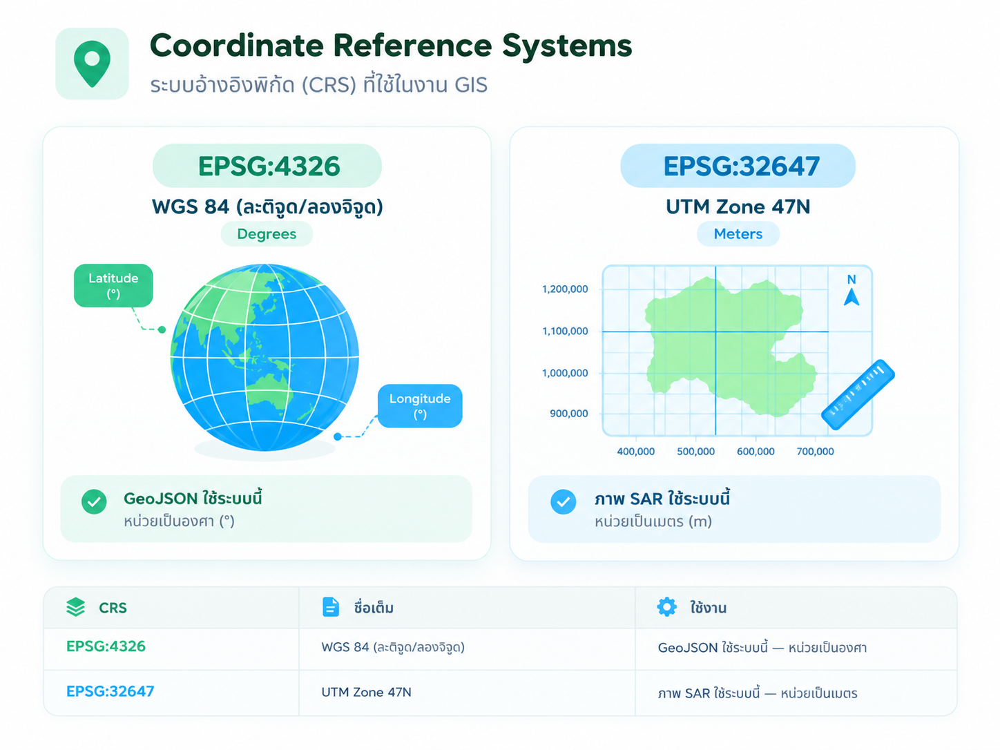

> 💡 ไม่ต้องกังวล — เครื่องมือ `geoai` ที่เราจะใช้ในบทถัดไปจะ **แปลงให้อัตโนมัติ** เมื่อ CRS ต่างกัน

In [12]:
# ═══════════════════════════════════════════════════════════
# CELL 3.2 — คำนวณพื้นที่ของแปลงปาล์ม
# ═══════════════════════════════════════════════════════════
# ต้องแปลง CRS เป็น UTM (หน่วยเมตร) ก่อน จึงจะคำนวณพื้นที่ได้ถูกต้อง

gdf_utm = gdf.to_crs("EPSG:32647")  # แปลงเป็น UTM Zone 47N (หน่วยเมตร)

# คำนวณพื้นที่แต่ละแปลง
gdf_utm["area_m2"]  = gdf_utm.geometry.area           # ตารางเมตร
gdf_utm["area_rai"] = gdf_utm["area_m2"] / 1600       # ไร่ (1 ไร่ = 1,600 ตร.ม.)

# ── สรุปพื้นที่ ──
total_rai = gdf_utm["area_rai"].sum()
print(f"📐 สรุปพื้นที่แปลงปาล์ม")
print(f"   จำนวนแปลง         : {len(gdf_utm):,} แปลง")
print(f"   พื้นที่รวมทั้งหมด    : {total_rai:,.2f} ไร่")
print(f"   พื้นที่เฉลี่ยต่อแปลง  : {gdf_utm['area_rai'].mean():.2f} ไร่")
print(f"   แปลงใหญ่สุด        : {gdf_utm['area_rai'].max():.2f} ไร่")
print(f"   แปลงเล็กสุด        : {gdf_utm['area_rai'].min():.2f} ไร่")

📐 สรุปพื้นที่แปลงปาล์ม
   จำนวนแปลง         : 4,726 แปลง
   พื้นที่รวมทั้งหมด    : 131,364.08 ไร่
   พื้นที่เฉลี่ยต่อแปลง  : 27.80 ไร่
   แปลงใหญ่สุด        : 565.38 ไร่
   แปลงเล็กสุด        : 0.00 ไร่


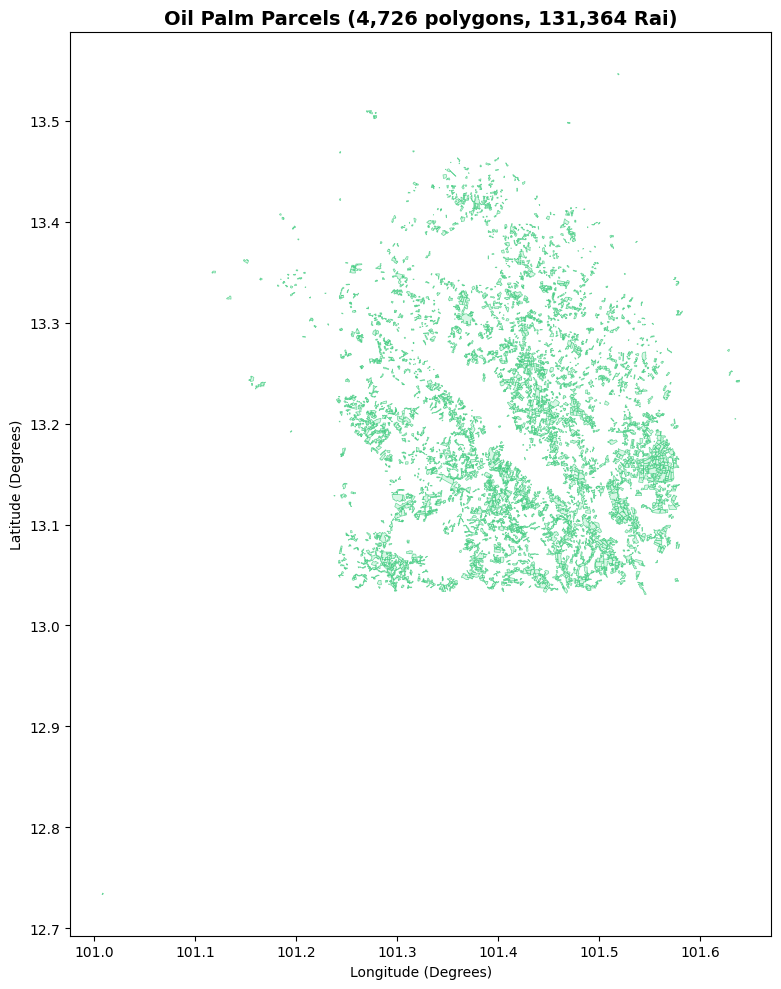

✅ Oil palm parcels map — Each polygon represents 1 parcel.


In [15]:
# ═══════════════════════════════════════════════════════════
# CELL 3.3 — วาดแผนที่แปลงปาล์มทั้งหมด
# ═══════════════════════════════════════════════════════════

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf.plot(
    ax=ax,
    color="#C8F5DA",       # สีเขียวอ่อน (Mint Green) 
    edgecolor="#35C778",   # เส้นขอบเขียวเข้ม
    linewidth=0.5,
    alpha=0.7,
)

ax.set_title(
    f"Oil Palm Parcels ({len(gdf):,} polygons, {total_rai:,.0f} Rai)",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Longitude (Degrees)")
ax.set_ylabel("Latitude (Degrees)")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

print("✅ Oil palm parcels map — Each polygon represents 1 parcel.")


---

## ขั้นตอนที่ 4 — อ่านและทำความเข้าใจภาพ Sentinel-1 SAR

### ภาพดาวเทียมเก็บอยู่ในรูปแบบ GeoTIFF (.tif)

ภาพดาวเทียมไม่ใช่ไฟล์ภาพธรรมดาอย่าง JPEG หรือ PNG  
แต่เป็น **GeoTIFF** — ไฟล์ภาพที่ฝังข้อมูลพิกัดภูมิศาสตร์เอาไว้

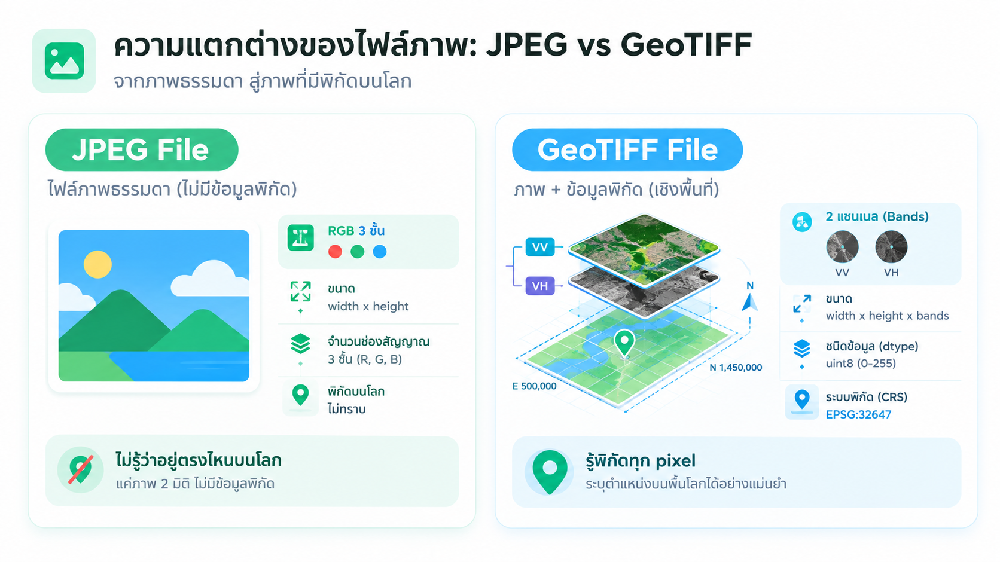
**ข้อมูลสำคัญของภาพ SAR ที่เราใช้:**

| คุณสมบัติ | ค่า | ความหมาย |
|---|---|---|
| Bands | 2 | ชั้นข้อมูล 2 ชั้น: VV (band 1), VH (band 2) |
| CRS | EPSG:32647 | ระบบพิกัด UTM Zone 47N (หน่วยเมตร) |
| dtype | uint8 | ตัวเลขจำนวนเต็ม 0-255 (ถ้าเป็น 0 = ไม่มีข้อมูล) |
| ขนาด | ~1843 × 1804 px | ภาพ clip ที่ตัดมาเฉพาะพื้นที่ศึกษา |

In [16]:
# ═══════════════════════════════════════════════════════════
# CELL 4.1 — อ่านข้อมูลเบื้องต้นของภาพ SAR
# ═══════════════════════════════════════════════════════════
# rasterio.open() เปิดไฟล์ GeoTIFF โดยไม่โหลดข้อมูลทั้งหมดเข้า RAM จะอ่านเฉพาะ "หัว" ของไฟล์ (metadata) ก่อน
# เพื่อให้เราตรวจสอบความถูกต้องเบื้องต้น (เช่น ขนาดพิกเซล, ระบบพิกัด, จำนวน Bands)


with rasterio.open(SAR_PATH) as src:
    print(f"📡 ข้อมูลภาพ Sentinel-1 SAR")
    print(f"   ไฟล์       : {os.path.basename(SAR_PATH)}")
    print(f"   ขนาด       : {src.width} x {src.height} pixels")
    print(f"   จำนวน bands: {src.count} (VV, VH)")
    print(f"   ชนิดข้อมูล  : {src.dtypes[0]} (ตัวเลข 0–255)")
    print(f"   ระบบพิกัด   : {src.crs}")
    print(f"   nodata     : {src.nodata}")
    print(f"   bounds     : {src.bounds}")
    
    # อ่านข้อมูลทั้ง 2 bands เข้ามา
    sar_data = src.read()  # shape: (2, height, width)
    
print(f"\n   shape ข้อมูล: {sar_data.shape} = (bands, height, width)")
print(f"   VV (band 1) — min: {sar_data[0].min()}, max: {sar_data[0].max()}")
print(f"   VH (band 2) — min: {sar_data[1].min()}, max: {sar_data[1].max()}")

📡 ข้อมูลภาพ Sentinel-1 SAR
   ไฟล์       : Sentinel-1_IW_mosaic_2025_M12_47PQQ_0_0_clif.tif
   ขนาด       : 1843 x 1804 pixels
   จำนวน bands: 2 (VV, VH)
   ชนิดข้อมูล  : uint8 (ตัวเลข 0–255)
   ระบบพิกัด   : EPSG:32647
   nodata     : 0.0
   bounds     : BoundingBox(left=742920.0, bottom=1442260.0, right=779780.0, top=1478340.0)

   shape ข้อมูล: (2, 1804, 1843) = (bands, height, width)
   VV (band 1) — min: 0, max: 255
   VH (band 2) — min: 0, max: 255


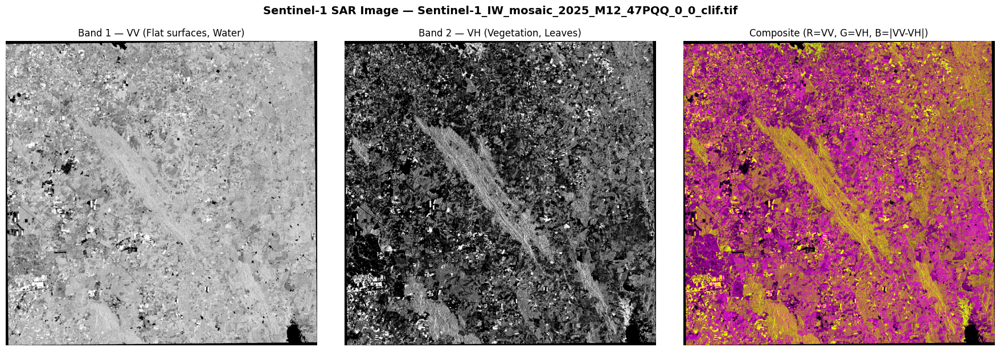

✅ Bright areas = High reflection (e.g., Buildings, Trees)
   Dark areas   = Low reflection (e.g., Still water, Flat plains)

🎨 How to read the Composite Image (Image 3):
   • Yellow tones : Vegetation, forests, or crops (high VH reflection)
   • Purple tones   : Urban areas, bare soil, or buildings (high VV reflection)
   • Black tones   : Water bodies or very smooth flat surfaces (low reflection in all bands)


In [20]:
# ═══════════════════════════════════════════════════════════
# CELL 4.2 — แสดงภาพ SAR ทั้ง VV และ VH
# ═══════════════════════════════════════════════════════════
# SAR ไม่มีสี — แสดงเป็นภาพขาวดำ (grayscale)
# ใช้ percentile stretch เพื่อให้เห็นรายละเอียดชัดขึ้น

def stretch_percentile(band, p_low=2, p_high=98):
    """ยืดค่า pixel ให้เต็มช่วง 0-1 ตาม percentile
    ช่วยให้ภาพ SAR ที่มืดทึบ ดูชัดเจนขึ้น"""
    vmin, vmax = np.nanpercentile(band, [p_low, p_high])
    return np.clip((band - vmin) / (vmax - vmin + 1e-6), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Band 1 = VV
vv_stretched = stretch_percentile(sar_data[0])
axes[0].imshow(vv_stretched, cmap="gray")
axes[0].set_title("Band 1 — VV (Flat surfaces, Water)", fontsize=12)
axes[0].axis("off")

# Band 2 = VH
vh_stretched = stretch_percentile(sar_data[1])
axes[1].imshow(vh_stretched, cmap="gray")
axes[1].set_title("Band 2 — VH (Vegetation, Leaves)", fontsize=12)
axes[1].axis("off")

# รวม VV/VH เป็นภาพ composite (R=VV, G=VH, B=VV-VH)
composite = np.stack([
    vv_stretched,                         # Red channel  = VV
    vh_stretched,                         # Green channel = VH
    np.abs(vv_stretched - vh_stretched),  # Blue channel  = ความต่าง
], axis=-1)
axes[2].imshow(composite)
axes[2].set_title("Composite (R=VV, G=VH, B=|VV-VH|)", fontsize=12)
axes[2].axis("off")

plt.suptitle(f"Sentinel-1 SAR Image — {os.path.basename(SAR_PATH)}", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("✅ Bright areas = High reflection (e.g., Buildings, Trees)")
print("   Dark areas   = Low reflection (e.g., Still water, Flat plains)")
print()
print("🎨 How to read the Composite Image (Image 3):")
print("   • Yellow tones : Vegetation, forests, or crops (high VH reflection)")
print("   • Purple tones   : Urban areas, bare soil, or buildings (high VV reflection)")
print("   • Black tones   : Water bodies or very smooth flat surfaces (low reflection in all bands)")



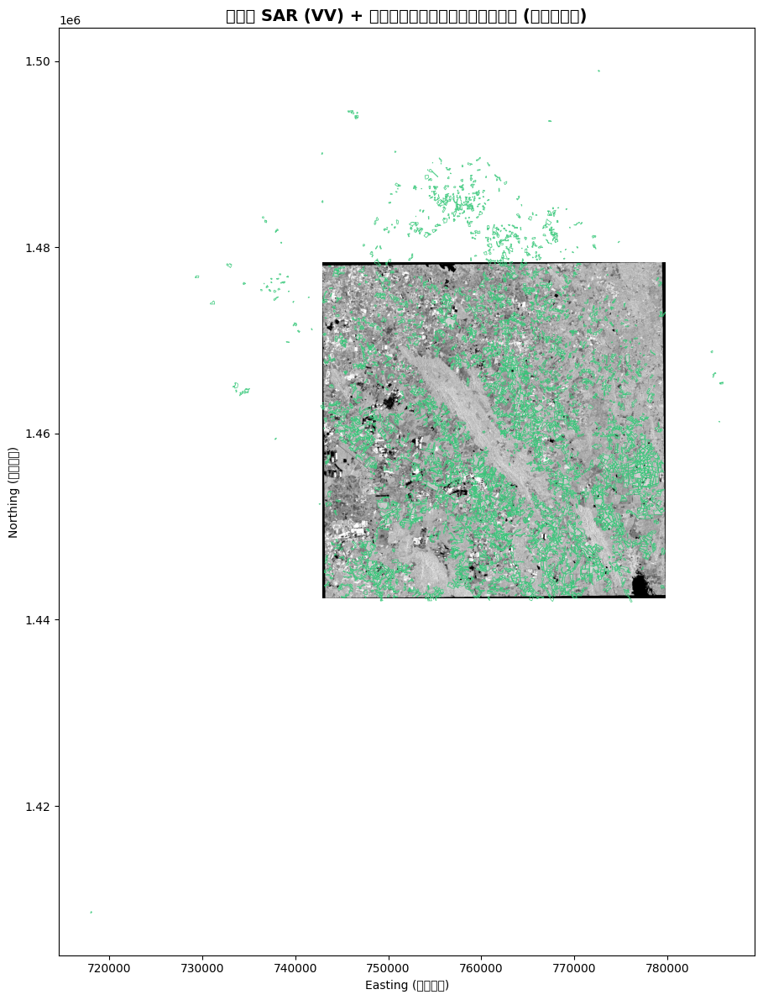

✅ เส้นสีเขียว = ขอบเขตแปลงปาล์มจริง (GeoJSON)
   พื้นหลังขาวดำ = ภาพ SAR จากดาวเทียม
   → ตำแหน่ง GeoJSON ซ้อนทับพื้นที่ SAR ถูกต้อง = พร้อมใช้สอน AI!


In [21]:
# ═══════════════════════════════════════════════════════════
# CELL 4.3 — ซ้อนขอบแปลงปาล์มบนภาพ SAR
# ═══════════════════════════════════════════════════════════
# เพื่อดูว่า "คำเฉลย" (GeoJSON) อยู่ตรงไหนบนภาพดาวเทียม
# ต้องแปลง CRS ของ GeoJSON ให้ตรงกับ SAR ก่อน

with rasterio.open(SAR_PATH) as src:
    sar_crs = src.crs
    sar_bounds = src.bounds
    sar_transform = src.transform
    vv_band = src.read(1)

# แปลง CRS ของแปลงปาล์ม → ให้ตรงกับ SAR
gdf_match = gdf.to_crs(sar_crs)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# แสดงภาพ SAR เป็นพื้นหลัง (ใช้ rasterio extent)
extent = [sar_bounds.left, sar_bounds.right, sar_bounds.bottom, sar_bounds.top]
vv_stretched = stretch_percentile(vv_band)
ax.imshow(vv_stretched, cmap="gray", extent=extent, origin="upper")

# ซ้อนขอบแปลงปาล์ม
gdf_match.boundary.plot(
    ax=ax,
    color="#35C778",   # เส้นขอบเขียว
    linewidth=0.6,
    alpha=0.8,
)

ax.set_title("ภาพ SAR (VV) + ขอบเขตแปลงปาล์ม (เขียว)", fontsize=14, fontweight="bold")
ax.set_xlabel("Easting (เมตร)")
ax.set_ylabel("Northing (เมตร)")
plt.tight_layout()
plt.show()

print("✅ เส้นสีเขียว = ขอบเขตแปลงปาล์มจริง (GeoJSON)")
print("   พื้นหลังขาวดำ = ภาพ SAR จากดาวเทียม")
print("   → ตำแหน่ง GeoJSON ซ้อนทับพื้นที่ SAR ถูกต้อง = พร้อมใช้สอน AI!")

---

## ขั้นตอนที่ 5 — อ่านและแสดงภาพ Google Satellite

ภาพ Google Satellite คือภาพถ่ายจากอวกาศแบบที่เราเห็นใน Google Maps  
เราจะ **ไม่ได้ใช้สอน AI** โดยตรง แต่ใช้เป็น **ตัวตรวจสอบ** ผลลัพธ์ในบทที่ 4

> 💡 เหมือนกับการตรวจข้อสอบ — ภาพ Google เป็น "ภาพจริง" ที่ช่วยเราดูด้วยตาเปล่าได้  
> ถ้าผลทำนายของ AI ตรงกับสิ่งที่เห็นในภาพ Google = โมเดลทำงานถูกต้อง
> 
> ⚠️ **หมายเหตุสำคัญ:** ภาพจาก Google Satellite มักจะเป็นภาพเก่า บางพื้นที่อาจไม่มีการอัปเดตมานานหลายปี ทำให้บางครั้งอาจเห็นพื้นที่ปาล์มไม่ตรงกับภาพ SAR ที่เป็นภาพปัจจุบัน

In [22]:
# ═══════════════════════════════════════════════════════════
# CELL 5.1 — อ่านและแสดงภาพ Google Satellite
# ═══════════════════════════════════════════════════════════

if os.path.exists(SAT_PATH):
    with rasterio.open(SAT_PATH) as src:
        print(f"🗺️ ข้อมูลภาพ Google Satellite")
        print(f"   ขนาด       : {src.width} x {src.height} pixels")
        print(f"   จำนวน bands: {src.count}")
        print(f"   ชนิดข้อมูล  : {src.dtypes[0]}")
        print(f"   ระบบพิกัด   : {src.crs}")
        
        # อ่าน 3 bands แรก (RGB)
        sat_r = src.read(1)
        sat_g = src.read(2)
        sat_b = src.read(3)
        sat_bounds = src.bounds
    
    # สร้างภาพ RGB
    sat_rgb = np.stack([sat_r, sat_g, sat_b], axis=-1)
    
    # ถ้าข้อมูลเป็น uint8 (0-255) ต้องหารด้วย 255 เพื่อให้ matplotlib แสดงผลถูกต้อง
    if sat_rgb.dtype == np.uint8:
        sat_rgb_display = sat_rgb.astype(np.float32) / 255.0
    else:
        sat_rgb_display = sat_rgb.astype(np.float32)
        p2, p98 = np.nanpercentile(sat_rgb_display, [2, 98])
        sat_rgb_display = np.clip((sat_rgb_display - p2) / (p98 - p2 + 1e-6), 0, 1)
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.imshow(sat_rgb_display)
    ax.set_title("ภาพ Google Satellite", fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    
    print("✅ ภาพนี้ใช้เปรียบเทียบกับผลทำนายของ AI ในบทที่ 4")
else:
    print("⚠️ ไม่พบไฟล์ภาพ Google Satellite — ข้ามขั้นตอนนี้ไปก่อน")
    print("   (ไม่กระทบบทเรียนหลัก เราจะใช้ภาพนี้ในบทที่ 4)")

⚠️ ไม่พบไฟล์ภาพ Google Satellite — ข้ามขั้นตอนนี้ไปก่อน
   (ไม่กระทบบทเรียนหลัก เราจะใช้ภาพนี้ในบทที่ 4)


In [23]:
# ═══════════════════════════════════════════════════════════
# CELL 5.2 — ซ้อนขอบแปลงปาล์มบนภาพ Google Satellite
# ═══════════════════════════════════════════════════════════

if os.path.exists(SAT_PATH):
    with rasterio.open(SAT_PATH) as src:
        sat_crs = src.crs
        sat_bounds_obj = src.bounds
    
    gdf_sat = gdf.to_crs(sat_crs)
    extent_sat = [sat_bounds_obj.left, sat_bounds_obj.right,
                  sat_bounds_obj.bottom, sat_bounds_obj.top]
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.imshow(sat_rgb_display, extent=extent_sat, origin="upper")
    
    gdf_sat.boundary.plot(
        ax=ax,
        color="#FFB347",   # สีส้มเพื่อให้เห็นชัดบนพื้นหลังเขียว
        linewidth=0.6,
        alpha=0.8,
    )
    
    ax.set_title("ภาพ Google Satellite + ขอบเขตแปลงปาล์ม (ส้ม)", fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    
    print("✅ เส้นสีส้ม = ขอบเขตแปลงปาล์มจริง (GeoJSON)")
    print("   → สังเกตว่าขอบเขตแปลงตรงกับพื้นที่ที่เป็นต้นปาล์มจริงในภาพ Google")
else:
    print("⚠️ ข้ามขั้นตอนนี้ — ไม่มีไฟล์ภาพ Google Satellite")

⚠️ ข้ามขั้นตอนนี้ — ไม่มีไฟล์ภาพ Google Satellite


---

## ขั้นตอนที่ 6 — รู้จัก Sentinel-3 เบื้องต้น (เนื้อหาเสริม)

### Sentinel-3 คืออะไร?

**Sentinel-3** เป็นดาวเทียมอีกดวงในโครงการ Copernicus ของยุโรป  
แตกต่างจาก Sentinel-1 (SAR) ตรงที่ **ถ่ายภาพด้วยแสง** — เหมือนกล้องถ่ายภาพ  
แต่สามารถ "มองเห็น" แสงได้มากกว่าตาเปล่ามนุษย์

### 6 bands หลักของ Sentinel-3 ที่ใช้งานบ่อย

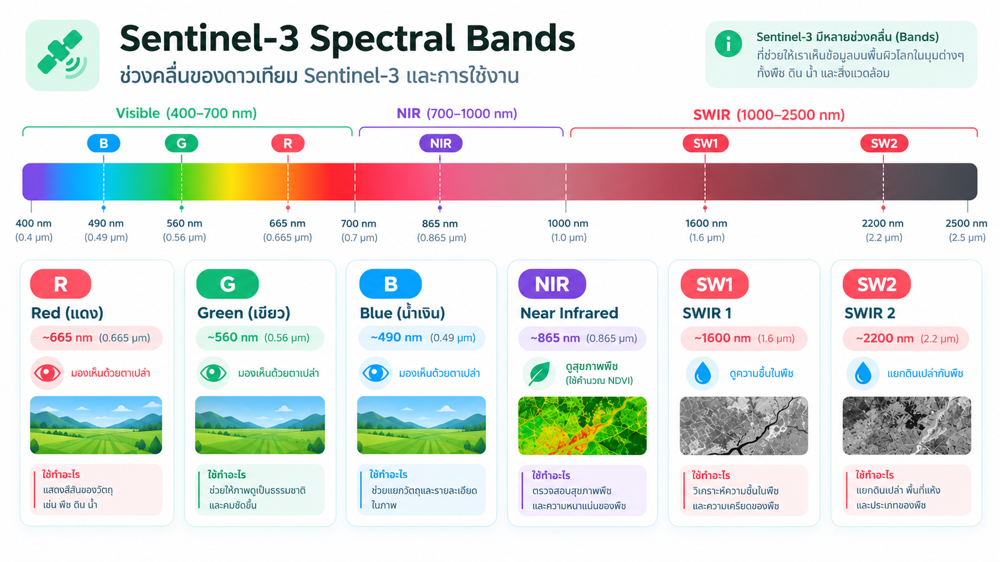

### NDVI — ดัชนีวัดสุขภาพพืช

**NDVI** (Normalized Difference Vegetation Index) คือสูตรคำนวณง่ายๆ ที่บอกว่าพืชแข็งแรงแค่ไหน:

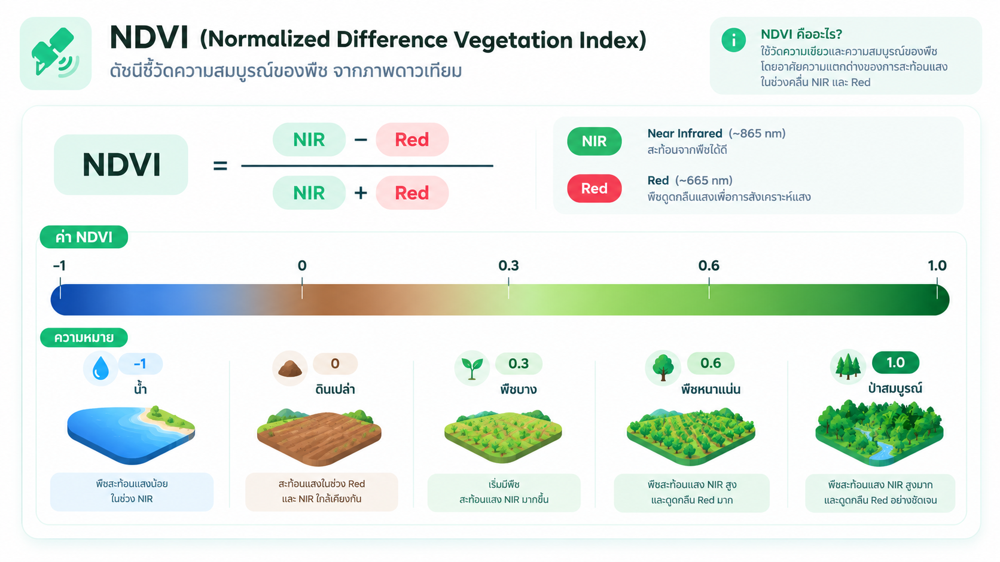

> 💡 **ใน Workshop นี้** เราใช้ Sentinel-1 (SAR) เป็นหลักในการจำแนกพื้นที่ปาล์ม  
> Sentinel-3 สามารถนำมาใช้ **ต่อยอด** ในอนาคตเพื่อวิเคราะห์สุขภาพของปาล์ม  
> เช่น ดูว่าแปลงไหนปาล์มแข็งแรง แปลงไหนต้องดูแลเพิ่ม

---

## ขั้นตอนที่ 7 — Sanity Check: ตรวจสอบข้อมูลก่อนไปต่อ

ก่อนจะเข้าบทที่ 2 (เตรียม Tiles สำหรับสอน AI) เรามาตรวจสอบว่าข้อมูลทุกอย่างสมบูรณ์

### Checklist สิ่งที่ต้องตรวจ:

```
☑ GeoJSON
  • มีข้อมูลแปลงปาล์ม 4,726 แปลง
  • CRS = EPSG:4326 (ลองจิจูด/ละติจูด)
  • ไม่มี geometry ที่ผิดรูป (invalid)

☑ SAR raster ทุกไฟล์
  • CRS เดียวกันหมด = EPSG:32647
  • จำนวน bands = 2 (VV, VH)
  • dtype = uint8 (0-255)
  • ไม่มีค่าแปลก (NaN, Inf)

☑ ขนาดและตำแหน่ง
  • GeoJSON ซ้อนทับบนภาพ SAR ได้ถูกต้อง
```

In [24]:
# ═══════════════════════════════════════════════════════════
# CELL 7.1 — ตรวจสอบ (Audit) ภาพ SAR ทุกไฟล์
# ═══════════════════════════════════════════════════════════
# ตรวจว่าทุกไฟล์มี CRS, bands, dtype ตรงกัน
# ขั้นตอนนี้สำคัญ — ถ้าข้อมูลไม่สอดคล้องกัน AI จะเรียนรู้ผิดพลาด

print("🔍 Audit ภาพ SAR ทุกไฟล์")
print("=" * 70)

for sar_file in sar_files:
    with rasterio.open(sar_file) as src:
        band1 = src.read(1)
        print(f"\n📄 {os.path.basename(sar_file)}")
        print(f"   CRS    : {src.crs}")
        print(f"   Size   : {src.width} x {src.height}")
        print(f"   Bands  : {src.count}")
        print(f"   dtype  : {src.dtypes[0]}")
        print(f"   nodata : {src.nodata}")
        print(f"   VV min : {np.nanmin(band1):.0f}, max: {np.nanmax(band1):.0f}")

print("\n" + "=" * 70)

# ── ตรวจ vector ──
print(f"\n📄 Vector: {os.path.basename(VECTOR_PATH)}")
print(f"   CRS      : {gdf.crs}")
print(f"   Features : {len(gdf):,}")
print(f"   Columns  : {list(gdf.columns)}")

# ตรวจ geometry ที่ invalid
invalid_count = (~gdf.is_valid).sum()
print(f"   Invalid  : {invalid_count} แปลง")
if invalid_count > 0:
    print("   ⚠️ พบ geometry ที่ไม่ถูกต้อง — อาจต้องซ่อมก่อนใช้งาน")
else:
    print("   ✅ geometry ทั้งหมดถูกต้อง")

print()
print("💡 สิ่งที่ต้องดู:")
print("   • CRS ของ SAR ทุกไฟล์ต้องเหมือนกัน (EPSG:32647)")
print("   • Bands ต้อง = 2 ทุกไฟล์ (ตรงกับ num_channels=2 ตอน train)")
print("   • dtype = uint8 (ถ้าเป็น float32 ต้องระวังเรื่อง value range)")
print("   • geoai จะ reproject vector CRS ให้อัตโนมัติ — ไม่ต้องแปลงเอง")

🔍 Audit ภาพ SAR ทุกไฟล์

📄 Sentinel-1_IW_mosaic_2025_M12_47PQQ_0_0_clif.tif
   CRS    : EPSG:32647
   Size   : 1843 x 1804
   Bands  : 2
   dtype  : uint8
   nodata : 0.0
   VV min : 0, max: 255

📄 Sentinel-1_IW_mosaic_2026_M01_47PQQ_0_0_clif.tif
   CRS    : EPSG:32647
   Size   : 1843 x 1804
   Bands  : 2
   dtype  : uint8
   nodata : 0.0
   VV min : 0, max: 255

📄 Sentinel-1_IW_mosaic_2026_M02_47PQQ_0_0_clif.tif
   CRS    : EPSG:32647
   Size   : 1843 x 1804
   Bands  : 2
   dtype  : uint8
   nodata : 0.0
   VV min : 0, max: 255

📄 Sentinel-1_IW_mosaic_2026_M03_47PQQ_0_0_clif.tif
   CRS    : EPSG:32647
   Size   : 1843 x 1804
   Bands  : 2
   dtype  : uint8
   nodata : 0.0
   VV min : 0, max: 255

📄 Sentinel-1_IW_mosaic_2026_M04_47PQQ_0_0_clif.tif
   CRS    : EPSG:32647
   Size   : 1843 x 1804
   Bands  : 2
   dtype  : uint8
   nodata : 0.0
   VV min : 0, max: 255

📄 Sentinel-1_IW_mosaic_2026_M05_47PQQ_0_0.tif
   CRS    : EPSG:32647
   Size   : 5004 x 5004
   Bands  : 2
   dtype  : u

---

## สรุปบทที่ 1

ในบทนี้เราได้เรียนรู้:

| หัวข้อ | สิ่งที่เรียนรู้ |
|---|---|
| **Google Colab** | สภาพแวดล้อมที่ใช้รัน Python ฟรีบน cloud |
| **GeoJSON** | ไฟล์ขอบเขตแปลงปาล์ม 4,726 แปลง — ใช้เป็น "คำเฉลย" สอน AI |
| **Sentinel-1 SAR** | ภาพดาวเทียมที่มองทะลุเมฆ, 2 bands (VV/VH), dtype=uint8 |
| **Google Satellite** | ภาพถ่ายจริง — ใช้ตรวจสอบผลลัพธ์ |
| **Sentinel-3** | ดาวเทียมที่ใช้ดูสุขภาพพืช — ต่อยอดวิเคราะห์สุขภาพปาล์ม |
| **CRS** | ระบบพิกัด (EPSG:4326 vs EPSG:32647) — เครื่องมือแปลงให้อัตโนมัติ |
| **Sanity Check** | ตรวจ CRS, bands, dtype ให้ตรงกันก่อนไปต่อ |


### 📚 ไปต่อ → [บทที่ 2 — เตรียม Tiles สำหรับสอน AI](02_prepare_tiles.ipynb)